In [8]:
import numpy as np 
import sunpy 
import sunpy.map 
from sunpy.data.sample import AIA_171_IMAGE
from matplotlib import patches # <--- patches like rectangle, circle, ellipse, and polygons...
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

In [3]:
smap = sunpy.map.Map(AIA_171_IMAGE)

/Users/yjzhu/miniconda3/envs/sunpy/lib/python3.12/site-packages/astropy/io/fits/hdu/image.py:610: VerifyWarning: Invalid 'BLANK' keyword in header.  The 'BLANK' keyword is only applicable to integer data, and will be ignored in this HDU.
  warnings.warn(msg, VerifyWarning)


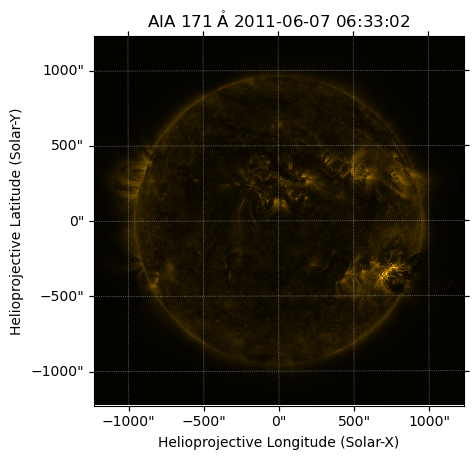

In [4]:
smap.plot()

In [9]:
# how to plot a rectangle to highlight the ROI
# first we plot the map on an matplotlib axis, and we overplot a rectangle upon that 

In [11]:
# peek the default plot settings
smap.plot_settings

{'cmap': 'sdoaia171',
 'interpolation': 'nearest',
 'origin': 'lower',
 'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x18e17de50>}

In [14]:
type(smap.plot_settings)

dict

In [12]:
smap.plot_settings["aspect"] = smap.scale.axis2/smap.scale.axis1

In [13]:
smap.plot_settings

{'cmap': 'sdoaia171',
 'interpolation': 'nearest',
 'origin': 'lower',
 'norm': <astropy.visualization.mpl_normalize.ImageNormalize at 0x18e17de50>,
 'aspect': <Quantity 1.>}

In [18]:
smap.data.shape #(ny, nx)

(1024, 1024)

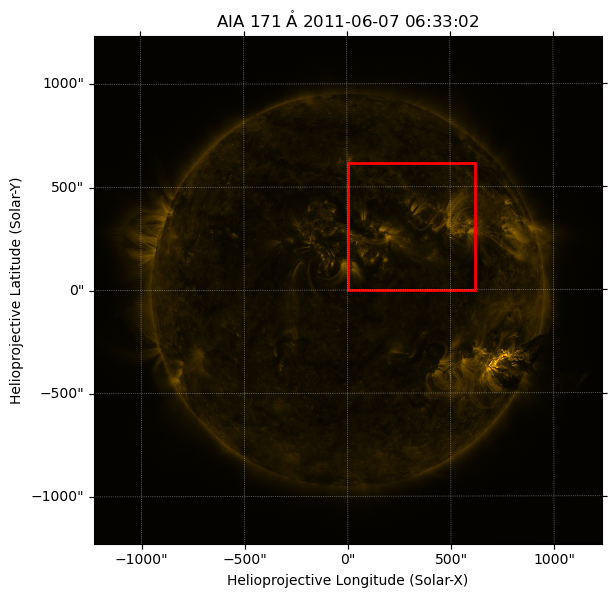

In [20]:
# plot the map 
fig = plt.figure(figsize=(6,6),layout="constrained")
ax = fig.add_subplot(111,projection=smap.wcs) 
# we divide the figure into a grid of 1 row, 1 column, and ax is created on the first grid element
smap.plot(axes=ax)

# create a Rectangle from pixels coordinates
rect_pixel = patches.Rectangle(xy=(512,512), # lower left coordinate of the rectangle in x, y
                               width=256, height=256,
                               facecolor="none", # no filling
                               edgecolor="red", # edge line color 
                               linewidth=2)

# we have to add this to our axis 
ax.add_patch(rect_pixel)

In [24]:
smap.wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'HPLN-TAN' 'HPLT-TAN' 
CRVAL : 0.00089530541880571 0.00038493926472939 
CRPIX : 512.5 512.5 
PC1_1 PC1_2  : 0.99999706448085 0.0024230207763071 
PC2_1 PC2_2  : -0.0024230207763071 0.99999706448085 
CDELT : 0.00066744222222222 0.00066744222222222 
NAXIS : 1024  1024

(array(551.67729327), array(552.6389917))


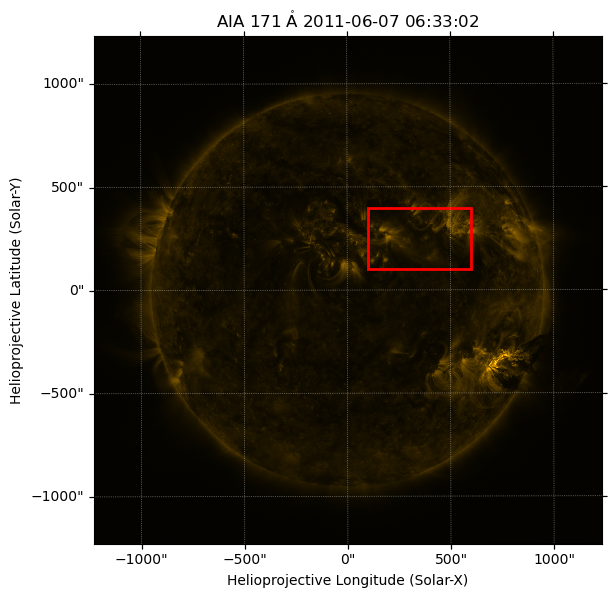

In [27]:
# plot the map 
fig = plt.figure(figsize=(6,6),layout="constrained")
ax = fig.add_subplot(111,projection=smap.wcs) 
# we divide the figure into a grid of 1 row, 1 column, and ax is created on the first grid element
smap.plot(axes=ax)

lower_left_coord = SkyCoord(100*u.arcsec, 100*u.arcsec, frame=smap.coordinate_frame)
lower_left_pixel = smap.wcs.world_to_pixel(lower_left_coord)

print(lower_left_pixel) # pixel index are zero-based, in (x,y)

width_coord = 500 *u.arcsec
width_pixel = (width_coord/smap.scale.axis1).to_value(u.pixel)
height_coord = 300 * u.arcsec
height_pixel = (height_coord/smap.scale.axis2).to_value(u.pixel)

rect_pixel_from_coord = patches.Rectangle(
    xy = lower_left_pixel,
    width = width_pixel,
    height = height_pixel,
    facecolor="none", edgecolor="red", linewidth=2)
ax.add_patch(rect_pixel_from_coord)

/Users/yjzhu/miniconda3/envs/sunpy/lib/python3.12/site-packages/astropy/visualization/wcsaxes/patches.py:198: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  super().__init__(vertices, **kwargs)


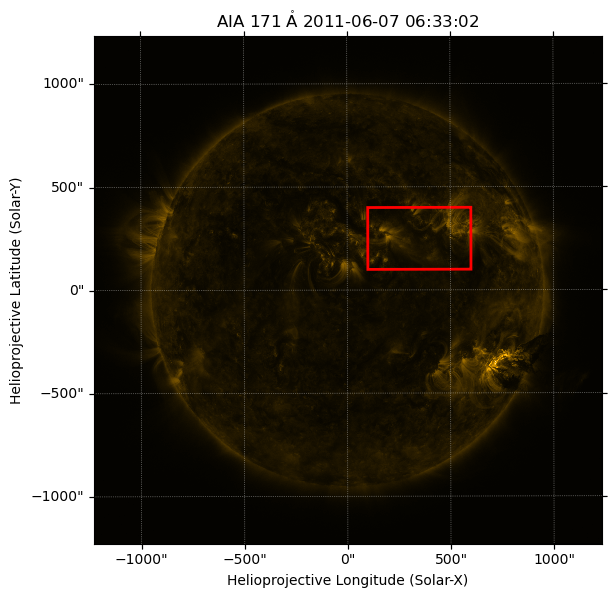

In [28]:
# plot the map 
fig = plt.figure(figsize=(6,6),layout="constrained")
ax = fig.add_subplot(111,projection=smap.wcs) 
# we divide the figure into a grid of 1 row, 1 column, and ax is created on the first grid element
smap.plot(axes=ax)
smap.draw_quadrangle(
    bottom_left=lower_left_coord,
    width=width_coord,
    height=height_coord,
    color="red",
    linewidth=2
)

TypeError: 'Longitude' object with a scalar value does not support indexing

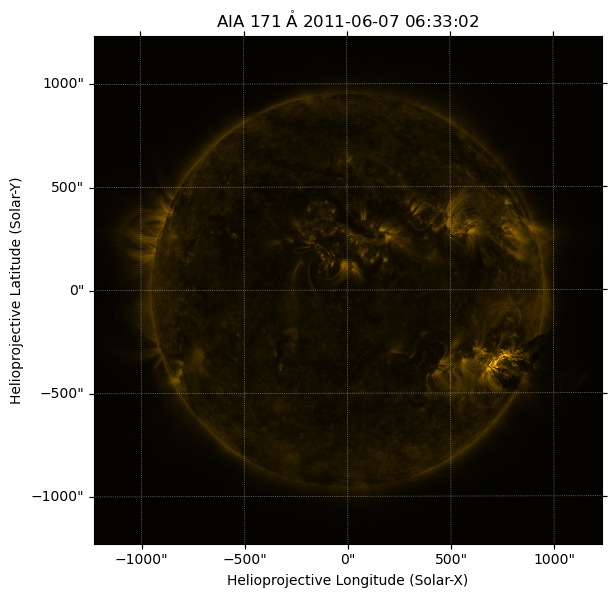

In [23]:
# plot the map 
fig = plt.figure(figsize=(6,6),layout="constrained")
ax = fig.add_subplot(111,projection=smap.wcs) 
# we divide the figure into a grid of 1 row, 1 column, and ax is created on the first grid element
smap.plot(axes=ax)

rect_skycoord = patches.Rectangle(
    xy=SkyCoord(100*u.arcsec, 100*u.arcsec, frame=smap.coordinate_frame),
    # lower left of the rectangle, in (x,y)
    width=400*u.arcsec,
    height=400*u.arcsec,
    transform=ax.get_transform(smap.coordinate_frame)
)

ax.add_patch(rect_skycoord)
    